# 05. Baseline Models - Automobile Loan Default Prediction


## 1. Setup

In [1]:
import os
import sys

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from src.config import RANDOM_STATE, TARGET
from src.data.data_cleaning import clean_and_split
from src.evaluation.metrics import evaluate_model, results_to_row
from src.preprocessing.feature_engineering import build_pipeline

train_df, test_df = clean_and_split()
X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Default rate (train):", round(y_train.mean(), 4))
print("Default rate (test):", round(y_test.mean(), 4))

X_train shape: (95372, 40)
X_test shape: (23844, 40)
Default rate (train): 0.081
Default rate (test): 0.081


## 2. Random Forest

Bagging ensemble. Note this is a *second*, independent Random Forest - a different one already runs inside the pipeline's `ImportanceFeatureSelector` step (feature selection), this one is the actual candidate model, fit and scored on the selected/scaled features that step produces.

In [3]:
from src.models.random_forest import build_random_forest_pipeline

rf_pipeline = build_random_forest_pipeline()

rf_results = evaluate_model(rf_pipeline, X_train, y_train, model_name="random_forest", cv=5)

for key, value in rf_results.items():
    print(f"{key}: {value}")

model_name: random_forest
cv_folds: 5
threshold: 0.5
roc_auc_mean: 0.7740530162105269
roc_auc_std: 0.00399387962965928
pr_auc_mean: 0.3575537792965477
pr_auc_std: 0.00932055501149178
recall_mean: 0.16338598521052367
precision_mean: 0.6320702646114715
f1_mean: 0.25954910625331074
confusion_matrix: [[86910, 738], [6462, 1262]]
fit_seconds: 42.23


In [4]:
rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline[:-1].transform(X_train).columns
rf_importances = pd.Series(
    rf_pipeline.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

print("Top 10 Random Forest feature importances:")
print(rf_importances.head(10))

Top 10 Random Forest feature importances:
score_mean           0.087051
score_min            0.070747
Score_Source_2       0.056280
Score_Source_3       0.049631
Age_Years            0.046665
Employed_Days        0.044843
Credit_Loan_Ratio    0.044656
ID_Days              0.043860
Registration_Days    0.042627
Credit_Amount        0.040610
dtype: float64


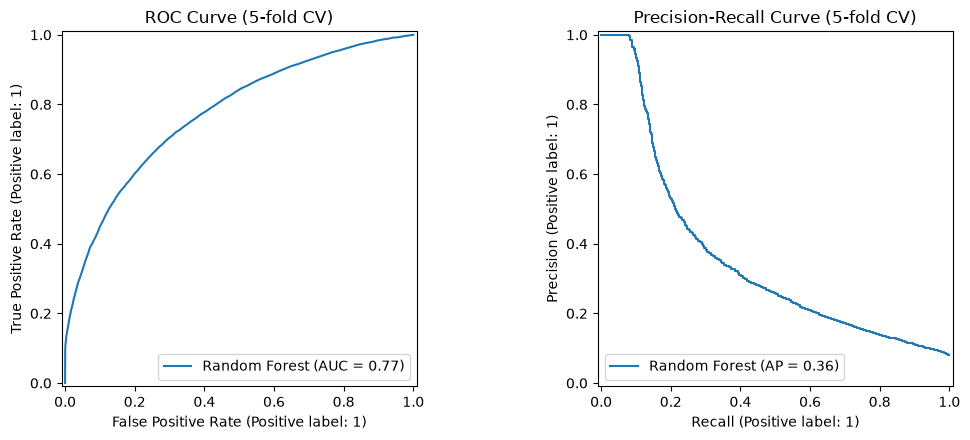

In [5]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_cv_proba = cross_val_predict(rf_pipeline, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_train, rf_cv_proba, ax=axes[0], name="Random Forest")
axes[0].set_title("ROC Curve (5-fold CV)")
PrecisionRecallDisplay.from_predictions(y_train, rf_cv_proba, ax=axes[1], name="Random Forest")
axes[1].set_title("Precision-Recall Curve (5-fold CV)")
plt.tight_layout()

figures_dir = "experiments/figures" if os.path.exists("experiments/figures") else "../experiments/figures"
plt.savefig(os.path.join(figures_dir, "05_random_forest_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()

In [6]:
results_dir = "experiments/results" if os.path.exists("experiments/results") else "../experiments/results"
experiments_path = os.path.join(results_dir, "experiments.csv")

row = results_to_row(rf_results)
row.to_csv(experiments_path, mode="a", header=not os.path.exists(experiments_path), index=False)

print(f"Logged to {experiments_path}")
pd.read_csv(experiments_path)

Logged to ../experiments/results\experiments.csv


,model_name,cv_folds,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit_seconds,tn,fp,fn,tp
0,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.63207,0.259549,48.20,86910,738,6462,1262
1,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.63207,0.259549,42.23,86910,738,6462,1262


**Finding:** Random Forest 5-fold CV - ROC-AUC 0.774, PR-AUC 0.358 (both stronger than the Logistic Regression baseline). At the default 0.5 threshold, recall is only 0.163 - `class_weight="balanced"` alone doesn't push RF's predicted probabilities the way it does for Logistic Regression, so most actual defaulters are currently missed. Threshold tuning (Stage 7) will matter more for this model than for the linear baseline.

**Decision:** ported to `src/models/random_forest.py` as `build_random_forest_pipeline()`.

## 3. Decision Tree
Single interpretable tree baseline with `class_weight='balanced'` and `max_depth=6`.

In [7]:
import joblib
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
from src.models.decision_tree import train_decision_tree, evaluate_decision_tree, save_decision_tree_model


### 3.1 Load Preprocessed Data

In [8]:
data_dir = "../data/processed" if os.path.exists("../data/processed") else "data/processed"
X_train_proc = joblib.load(os.path.join(data_dir, "X_train.joblib"))
y_train_proc = joblib.load(os.path.join(data_dir, "y_train.joblib"))
X_test_proc = joblib.load(os.path.join(data_dir, "X_test.joblib"))
y_test_proc = joblib.load(os.path.join(data_dir, "y_test.joblib"))

print("Training samples:", X_train_proc.shape[0])
print("Testing samples: ", X_test_proc.shape[0])


Training samples: 97484
Testing samples:  24372


### 3.2 Train Decision Tree
We set `max_depth=6` and `class_weight='balanced'`.

In [9]:
dt_model, train_time = train_decision_tree(X_train_proc, y_train_proc, max_depth=6, min_samples_leaf=20)
print(f"Trained in {train_time:.2f} seconds.")


Trained in 1.51 seconds.


### 3.3 Model Evaluation

In [10]:
metrics, cm = evaluate_decision_tree(dt_model, X_test_proc, y_test_proc)

# Show nicely formatted table
results_df = pd.DataFrame([metrics])
results_df


,accuracy,precision,recall,f1_score,roc_auc,pr_auc,tn,fp,fn,tp
0,0.6837,0.1466,0.6049,0.236,0.7058,0.1727,15471,6932,778,1191


### 3.4 Confusion Matrix

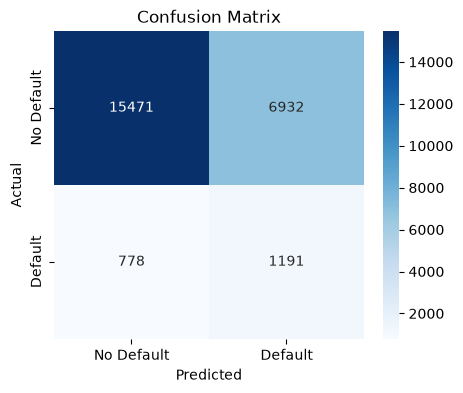

Correct Non-Defaults (TN): 15471 | Wrong Alarms (FP): 6932
Missed Defaults (FN):      778  | Caught Defaults (TP): 1191


In [11]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Correct Non-Defaults (TN): {metrics['tn']} | Wrong Alarms (FP): {metrics['fp']}")
print(f"Missed Defaults (FN):      {metrics['fn']}  | Caught Defaults (TP): {metrics['tp']}")

### 3.5 ROC and Precision-Recall Curves

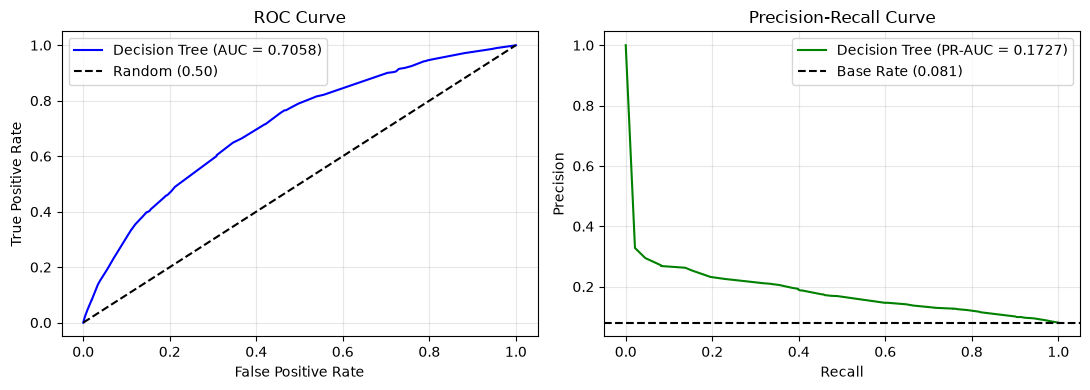

In [12]:
y_proba = dt_model.predict_proba(X_test_proc)[:, 1]

fpr, tpr, _ = roc_curve(y_test_proc, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_proc, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"Decision Tree (AUC = {metrics['roc_auc']})", color="blue")
axes[0].plot([0, 1], [0, 1], "k--", label="Random (0.50)")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_vals, precision_vals, label=f"Decision Tree (PR-AUC = {metrics['pr_auc']})", color="green")
axes[1].axhline(y=y_test_proc.mean(), color="k", linestyle="--", label=f"Base Rate ({y_test_proc.mean():.3f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
figures_dir = "experiments/figures" if os.path.exists("experiments/figures") else "../experiments/figures"
plt.savefig(os.path.join(figures_dir, "05_decision_tree_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()


### 3.6 Save Model

In [13]:
models_dir = "../models/baseline" if os.path.exists("../models/baseline") else "models/baseline"
save_decision_tree_model(dt_model, os.path.join(models_dir, "decision_tree.pkl"))


Model saved to: ../models/baseline\decision_tree.pkl


'../models/baseline\\decision_tree.pkl'

### 3.7 Why These Settings Were Used

#### 1. Why `class_weight='balanced'`?
* In this dataset, **92%** of people pay their loan on time, and only **8%** default.
* If we do not use `balanced`, the tree will simply predict "No Default" for everyone. That gives a fake high accuracy of 92%, but catches **0 defaulters**.
* Setting `class_weight='balanced'` forces the tree to pay attention to defaulters, allowing it to catch **~60% of real defaulters**.

#### 2. Why `max_depth=6`?
* If a decision tree is allowed to grow with no limit, it grows 20+ levels deep and memorizes noise in the training data (overfitting).
* Capping the depth at **6** keeps the rules simple and prevents overfitting, so the model works well on new test data.


### 3.8 5-Fold Cross-Validation & Experiment Logging

Evaluate the Decision Tree pipeline with 5-fold stratified cross-validation and log to `experiments.csv`.

In [14]:
from src.models.decision_tree import build_decision_tree_pipeline

dt_pipeline = build_decision_tree_pipeline()
dt_results = evaluate_model(dt_pipeline, X_train, y_train, model_name="decision_tree", cv=5)

for key, value in dt_results.items():
    print(f"{key}: {value}")

row_dt = results_to_row(dt_results)
row_dt.to_csv(experiments_path, mode="a", header=not os.path.exists(experiments_path), index=False)

print(f"\nLogged to {experiments_path}")
pd.read_csv(experiments_path)


model_name: decision_tree
cv_folds: 5
threshold: 0.5
roc_auc_mean: 0.7081826318431956
roc_auc_std: 0.003783205094030031
pr_auc_mean: 0.1807175642717052
pr_auc_std: 0.004464595295450644
recall_mean: 0.60668217717189
precision_mean: 0.15185553323712758
f1_mean: 0.2422317714795962
confusion_matrix: [[61284, 26364], [3038, 4686]]
fit_seconds: 19.86

Logged to ../experiments/results\experiments.csv


,model_name,cv_folds,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit_seconds,tn,fp,fn,tp
0,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.632070,0.259549,48.20,86910,738,6462,1262
1,random_forest,5,0.5,0.774053,0.003994,0.357554,0.009321,0.163386,0.632070,0.259549,42.23,86910,738,6462,1262
2,decision_tree,5,0.5,0.708183,0.003783,0.180718,0.004465,0.606682,0.151856,0.242232,19.86,61284,26364,3038,4686


**Finding:** Decision Tree 5-fold CV achieves ROC-AUC 0.708, PR-AUC 0.181 (test set: ROC-AUC 0.706, PR-AUC 0.173). Setting `class_weight='balanced'` allows the tree to catch **60.5% of actual defaulters** (Recall = 0.605), which is much higher than Random Forest at the 0.5 threshold (0.163). However, precision is low (0.152) with many false alarms.

**Decision:** ported to `src/models/decision_tree.py` as `build_decision_tree_pipeline()` and `train_decision_tree()`, and saved to `models/baseline/decision_tree.pkl` as our interpretable non-linear baseline.